In [3]:
import sys

sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML
from pathlib import Path
import json
import h5py

from pim.viz import animate_scene, make_waterfall, save_animation
import helpers.nb_viz as nb_viz
from helpers.nb_utils import load_sample

In [4]:
DATASET_PATH = "../datasets/3_fixed_refl_inview_brighter_train/dataset.h5"  # Generate from ../scripts/generate_dataset.py

with h5py.File(DATASET_PATH, "r") as f:
    meta = json.loads(f.attrs["config_json"])
    print(f"generated : {meta['generated_at']}")
    print(f"n_samples : {meta['dataset']['n_samples']:,}")
    print()
    for key, ds in f.items():
        print(f"  {key:12s}  {str(ds.shape):30s}  {ds.dtype}")

generated : 2026-03-30T10:30:27
n_samples : 100,000

  colors        (100000, 2, 3)                  float32
  is_visible    (100000, 40, 2)                 bool
  n_objects     (100000,)                       uint8
  obs_depth     (100000, 40, 128)               float32
  obs_id        (100000, 40, 128)               int8
  obs_intensity  (100000, 40, 128)               float32
  positions     (100000, 40, 2, 2)              float32
  radii         (100000, 2)                     float32
  reflectivities  (100000, 2)                     float32
  seeds         (100000,)                       int64
  velocities    (100000, 40, 2, 2)              float32


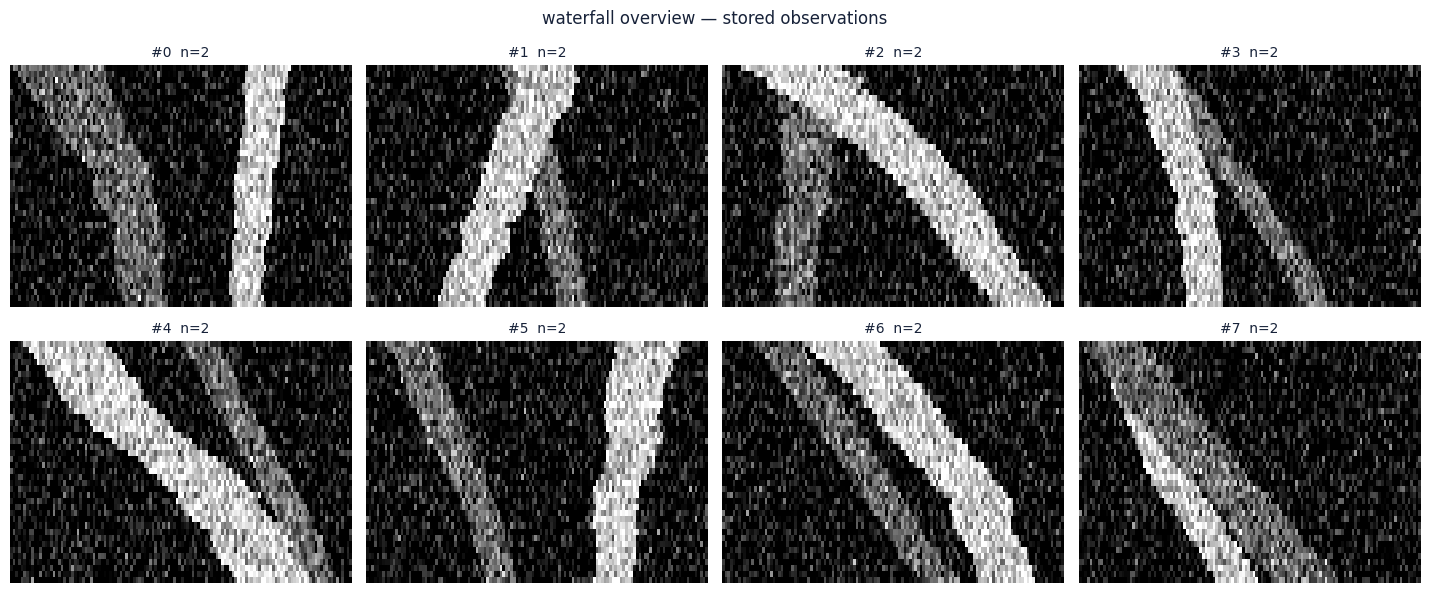

In [5]:
N_SHOW = 8
indices = np.arange(N_SHOW)  # or np.random.choice(n_total, N_SHOW, replace=False)

fig, axes = plt.subplots(
    2, N_SHOW // 2, figsize=(N_SHOW * 1.8, 6), facecolor=nb_viz._BG_HEX
)
fig.suptitle(
    "waterfall overview — stored observations", color=nb_viz._TEXT_COLOR, fontsize=12
)

for ax, idx in zip(axes.flat, indices):
    scene, obs_depth, obs_id, obs_intensity = load_sample(DATASET_PATH, idx)
    wf = make_waterfall(obs_depth, obs_id, obs_intensity, scene)
    ax.imshow(wf, aspect="auto", origin="upper", interpolation="nearest")
    ax.set_title(
        f"#{idx}  n={scene.positions.shape[1]}", color=nb_viz._TEXT_COLOR, fontsize=10
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [6]:
idx = 0
scene, obs_depth, obs_id, obs_intensity = load_sample(DATASET_PATH, idx)
anim = animate_scene(scene, obs_depth, obs_id, obs_intensity, title=f"sample {idx}")
plt.close()
HTML(anim.to_jshtml())

/home/sevan/research/physically-implicit-modeling/notebooks/../pim/viz.py:206: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circ = plt.Circle(


In [19]:
out_dir = Path("../outputs/dataset_2")
out_dir.mkdir(parents=True, exist_ok=True)

for idx in range(5):
    scene, obs_depth, obs_id, obs_intensity = load_sample(DATASET_PATH, idx)
    anim = animate_scene(scene, obs_depth, obs_id, obs_intensity, title=f"sample {idx}")
    save_animation(anim, str(out_dir / f"sample_{idx:04d}.gif"), fps=20)
    plt.close()

/home/sevan/research/physically-implicit-modeling/pim/viz.py:206: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circ = plt.Circle(


saved → ../outputs/dataset_2/sample_0000.gif


/home/sevan/research/physically-implicit-modeling/pim/viz.py:206: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circ = plt.Circle(


saved → ../outputs/dataset_2/sample_0001.gif


/home/sevan/research/physically-implicit-modeling/pim/viz.py:206: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circ = plt.Circle(


saved → ../outputs/dataset_2/sample_0002.gif


/home/sevan/research/physically-implicit-modeling/pim/viz.py:206: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circ = plt.Circle(


saved → ../outputs/dataset_2/sample_0003.gif


/home/sevan/research/physically-implicit-modeling/pim/viz.py:206: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circ = plt.Circle(


saved → ../outputs/dataset_2/sample_0004.gif
